In [24]:
import torch
import trimesh
import roma
import math

import sys
sys.path.insert(0, "/Users/saptarshiMT/Music/meshsense/anny/src")
import anny

def main():
    model = anny.create_fullbody_model(
        all_phenotypes=True,
        local_changes=True,
        remove_unattached_vertices=True,
        triangulate_faces=True,
    ).to(device="mps", dtype=torch.float32)

    phenotype_kwargs = {
        "gender": 0,
        "age": 0.5,
        "height": 0.6,
        "weight": 1.0,
        "muscle": 10,
    }

    local_changes_kwargs = {
        "l-lowerleg-muscle-incr": 0.7,
        "r-lowerleg-muscle-incr": 0.7,
        "l-upperleg-fat-incr": 0.25,
        "r-upperleg-fat-incr": 0.25,
        "l-hand-fingers-length-incr": 0.2,
        "r-hand-fingers-length-incr": 0.2,
    }

    pose_parameters = {

        "root": roma.Rigid(
            linear=roma.rotvec_to_rotmat(
                torch.tensor([[-math.pi/2, 0.0, 0.0]], device=model.device, dtype=model.dtype)
            ),
            translation=None,
        ),

        # "shoulder01.L": roma.Rigid(
        #     linear=roma.rotvec_to_rotmat(
        #         torch.tensor([[ 0,0,-0.5]], device=model.device, dtype=model.dtype)
        #     ),
        #     translation=None,
        # ),

        # "lowerarm01.L": roma.Rigid(
        #     linear=roma.rotvec_to_rotmat(
        #         torch.tensor([[0.0, 0.0, 0.8]], device=model.device, dtype=model.dtype)
        #     ),
        #     translation=None,
        # ),

        # "upperarm01.L": roma.Rigid(
        #     linear=roma.rotvec_to_rotmat(
        #         torch.tensor([[ 0,0,0.5]], device=model.device, dtype=model.dtype)
        #     ),
        #     translation=None,
        # ),

        # "upperleg01.L": roma.Rigid(
        #     linear=roma.rotvec_to_rotmat(
        #         torch.tensor([[0.45, 0.0, 0.0]], device=model.device, dtype=model.dtype)
        #     ),
        #     translation=None,
        # ),

        "pelvis.R": roma.Rigid(
            linear=roma.rotvec_to_rotmat(
                torch.tensor([[0.0, 1.0, 0.0]], device=model.device, dtype=model.dtype)
            ),
            translation=None #torch.tensor([[0.0, 0.0, -0.3]], device=model.device, dtype=model.dtype),
        ),

        # "pelvis.L": roma.Rigid(
        #     linear=roma.rotvec_to_rotmat(
        #         torch.tensor([[0.0, -1.0, 0.0]], device=model.device, dtype=model.dtype)
        #     ),
        #     translation=None #torch.tensor([[0.0, 0.0, -0.3]], device=model.device, dtype=model.dtype),
        # ),

        # "lowerleg01.L": roma.Rigid(
        #     linear=roma.rotvec_to_rotmat(
        #         torch.tensor([[ 1.0,0.0,0.0]], device=model.device, dtype=model.dtype)
        #     ),
        #     translation=None,
        # ),

        # "foot.L": roma.Rigid(
        #     linear=roma.rotvec_to_rotmat(
        #         torch.tensor([[0.0,0.0,1.0]], device=model.device, dtype=model.dtype)
        #     ),
        #     translation=None,
        # ),
    }

    local_changes_kwargs = {
        key: value
        for key, value in local_changes_kwargs.items()
        if key in model.local_change_labels
    }

    with torch.no_grad():
        output = model(
            pose_parameters=pose_parameters,
            phenotype_kwargs=phenotype_kwargs,
            # local_changes_kwargs=local_changes_kwargs,
        )

    vertices = output["vertices"].squeeze(0).cpu().numpy()
    faces = model.faces.cpu().numpy()

    mesh = trimesh.Trimesh(vertices=vertices, faces=faces, process=False)
    mesh.visual = trimesh.visual.TextureVisuals(
        material=trimesh.visual.material.PBRMaterial(
            baseColorFactor=[0.55, 0.78, 0.82, 1.0],
            metallicFactor=0.0,
            roughnessFactor=0.7,
            doubleSided=True,
        )
    )

    print(f"Vertices: {len(vertices)}")
    print(f"Faces: {len(faces)}")
    print(f"Applied local changes: {local_changes_kwargs}")

    return mesh

mesh = main()
mesh.show()

Vertices: 13718
Faces: 27420
Applied local changes: {'l-lowerleg-muscle-incr': 0.7, 'r-lowerleg-muscle-incr': 0.7, 'l-upperleg-fat-incr': 0.25, 'r-upperleg-fat-incr': 0.25, 'l-hand-fingers-length-incr': 0.2, 'r-hand-fingers-length-incr': 0.2}


In [18]:
model = anny.create_fullbody_model(
    all_phenotypes=True,
    local_changes=True,
    remove_unattached_vertices=True,
    triangulate_faces=True,
).to(device="mps", dtype=torch.float32)

In [3]:
len(model.bone_labels)

163

In [4]:
model.bone_labels

['root',
 'pelvis.L',
 'upperleg01.L',
 'upperleg02.L',
 'lowerleg01.L',
 'lowerleg02.L',
 'foot.L',
 'toe1-1.L',
 'toe1-2.L',
 'toe2-1.L',
 'toe2-2.L',
 'toe2-3.L',
 'toe3-1.L',
 'toe3-2.L',
 'toe3-3.L',
 'toe4-1.L',
 'toe4-2.L',
 'toe4-3.L',
 'toe5-1.L',
 'toe5-2.L',
 'toe5-3.L',
 'pelvis.R',
 'upperleg01.R',
 'upperleg02.R',
 'lowerleg01.R',
 'lowerleg02.R',
 'foot.R',
 'toe1-1.R',
 'toe1-2.R',
 'toe2-1.R',
 'toe2-2.R',
 'toe2-3.R',
 'toe3-1.R',
 'toe3-2.R',
 'toe3-3.R',
 'toe4-1.R',
 'toe4-2.R',
 'toe4-3.R',
 'toe5-1.R',
 'toe5-2.R',
 'toe5-3.R',
 'spine05',
 'spine04',
 'spine03',
 'spine02',
 'breast.L',
 'breast.R',
 'spine01',
 'clavicle.L',
 'shoulder01.L',
 'upperarm01.L',
 'upperarm02.L',
 'lowerarm01.L',
 'lowerarm02.L',
 'wrist.L',
 'finger1-1.L',
 'finger1-2.L',
 'finger1-3.L',
 'metacarpal1.L',
 'finger2-1.L',
 'finger2-2.L',
 'finger2-3.L',
 'metacarpal2.L',
 'finger3-1.L',
 'finger3-2.L',
 'finger3-3.L',
 'metacarpal3.L',
 'finger4-1.L',
 'finger4-2.L',
 'finger4-3.L',

In [5]:
output = model()

In [6]:
output['bone_poses'].shape

torch.Size([1, 163, 4, 4])

In [7]:
model.bone_labels.index("upperarm01.R")

76

In [8]:
output['bone_poses'][:,76,:,:]

tensor([[[-0.7330, -0.6802,  0.0030, -0.1616],
         [ 0.0108, -0.0161, -0.9998, -0.0781],
         [ 0.6801, -0.7329,  0.0191,  0.4352],
         [ 0.0000,  0.0000,  0.0000,  1.0000]]], device='mps:0')

In [9]:
output["bone_poses"][0, :, :3, 3].shape

torch.Size([163, 3])

In [10]:
T = torch.tensor(
    [[-0.7330, -0.6802,  0.0030],
     [ 0.0108, -0.0161, -0.9998],
     [ 0.6801, -0.7329,  0.0191]],
    device=model.device,
    dtype=model.dtype,
)

roma.rotmat_to_rotvec(T.unsqueeze(0)) 

tensor([[ 0.6958, -1.7649,  1.8011]], device='mps:0')

In [11]:
import torch
import trimesh
import anny
import roma
import numpy as np

def make_keypoint_sphere(center, radius=0.025, color=[255, 40, 40, 255]):
    sphere = trimesh.creation.uv_sphere(radius=radius)
    sphere.apply_translation(center)
    sphere.visual.vertex_colors = color
    return sphere

def main():
    model = anny.create_fullbody_model(
        all_phenotypes=True,
        local_changes=True,
        remove_unattached_vertices=True,
        triangulate_faces=True,
    ).to(device="mps", dtype=torch.float32)

    phenotype_kwargs = {
        "gender": 0,
        "age": 0.5,
        "height": 0.6,
        "weight": 1.0,
        "muscle": 1.0,   # safer than 10
    }

    local_changes_kwargs = {
        "l-lowerleg-muscle-incr": 0.7,
        "r-lowerleg-muscle-incr": 0.7,
        "l-upperleg-fat-incr": 0.25,
        "r-upperleg-fat-incr": 0.25,
        "l-hand-fingers-length-incr": 0.2,
        "r-hand-fingers-length-incr": 0.2,
    }

    pose_parameters = {
        "lowerarm01.L": roma.Rigid(
            linear=roma.rotvec_to_rotmat(
                torch.tensor([[1.0, 0.0, 0.8]], device=model.device, dtype=model.dtype)
            ),
            translation=None,
        ),
        "upperarm01.R": roma.Rigid(
            linear=roma.rotvec_to_rotmat(
                torch.tensor([[0.0, 0.0, -0.5]], device=model.device, dtype=model.dtype)
            ),
            translation=None,
        ),
        "pelvis.L": roma.Rigid(
            linear=roma.rotvec_to_rotmat(
                torch.tensor([[0.45, 1.0, 0.5]], device=model.device, dtype=model.dtype)
            ),
            translation=None,
        ),
    }

    local_changes_kwargs = {
        key: value
        for key, value in local_changes_kwargs.items()
        if key in model.local_change_labels
    }

    with torch.no_grad():
        output = model(
            pose_parameters=pose_parameters,
            phenotype_kwargs=phenotype_kwargs,
            # local_changes_kwargs=local_changes_kwargs,
        )

    vertices = output["vertices"].squeeze(0).cpu().numpy()
    faces = model.faces.cpu().numpy()

    mesh = trimesh.Trimesh(vertices=vertices, faces=faces, process=False)
    mesh.visual = trimesh.visual.TextureVisuals(
        material=trimesh.visual.material.PBRMaterial(
            baseColorFactor=[0.55, 0.78, 0.82, 1.0],
            metallicFactor=0.0,
            roughnessFactor=0.7,
            doubleSided=True,
        )
    )

    mediapipe_to_anny = {
        0: "head",
        1: "eye.L",
        2: "eye.L",
        3: "eye.L",
        4: "eye.R",
        5: "eye.R",
        6: "eye.R",
        7: "head",
        8: "head",
        9: "oris04.L",
        10: "oris04.R",
        11: "shoulder01.L",
        12: "shoulder01.R",
        13: "lowerarm01.L",
        14: "lowerarm01.R",
        15: "wrist.L",
        16: "wrist.R",
        17: "finger5-1.L",
        18: "finger5-1.R",
        19: "finger2-1.L",
        20: "finger2-1.R",
        21: "finger1-1.L",
        22: "finger1-1.R",
        23: "pelvis.L",
        24: "pelvis.R",
        25: "lowerleg01.L",
        26: "lowerleg01.R",
        27: "foot.L",
        28: "foot.R",
        29: "foot.L",
        30: "foot.R",
        31: "toe2-1.L",
        32: "toe2-1.R",
    }

    bone_positions = output["bone_poses"][0, :, :3, 3]
    label_to_idx = {name: i for i, name in enumerate(model.bone_labels)}

    keypoints = []
    for mp_idx in range(33):
        bone_name = mediapipe_to_anny[mp_idx]
        bone_idx = label_to_idx[bone_name]
        xyz = bone_positions[bone_idx].detach().cpu().numpy()
        keypoints.append(xyz)

    keypoints = np.asarray(keypoints)

    scene = trimesh.Scene()
    scene.add_geometry(mesh, node_name="anny_mesh")

    for mp_idx, xyz in enumerate(keypoints):
        sphere = make_keypoint_sphere(
            center=xyz,
            radius=0.025,
            color=[255, 30, 30, 255],
        )
        scene.add_geometry(sphere, node_name=f"mp_{mp_idx}_{mediapipe_to_anny[mp_idx]}")

    print(f"Vertices: {len(vertices)}")
    print(f"Faces: {len(faces)}")
    print(f"MediaPipe-style keypoints: {keypoints.shape}")
    print(f"Applied local changes: {local_changes_kwargs}")

    return scene, keypoints

scene, keypoints = main()
scene.show()

Vertices: 13718
Faces: 27420
MediaPipe-style keypoints: (33, 3)
Applied local changes: {'l-lowerleg-muscle-incr': 0.7, 'r-lowerleg-muscle-incr': 0.7, 'l-upperleg-fat-incr': 0.25, 'r-upperleg-fat-incr': 0.25, 'l-hand-fingers-length-incr': 0.2, 'r-hand-fingers-length-incr': 0.2}


In [1]:
from rtmpose import *
import matplotlib.pyplot as plt

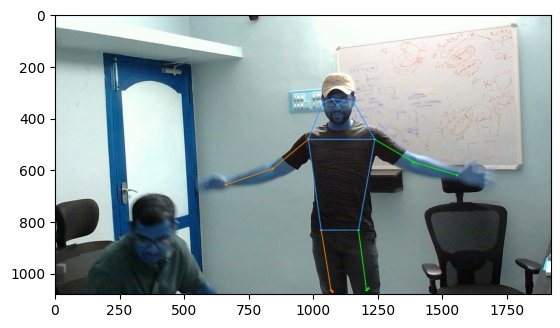

In [2]:

cap = cv2.VideoCapture('/Users/saptarshiMT/Music/meshsense/camera0.avi')
n = 10  # frame number to read
cap.set(cv2.CAP_PROP_POS_FRAMES, n)
ret, img = cap.read()
cap.release()

if ret:
    sess      = build_session('/Users/saptarshiMT/Downloads/20230831/rtmpose_onnx/rtmpose-m_simcc-body7_pt-body7_420e-256x192-e48f03d0_20230504/end2end.onnx', device='cpu')
    h, w      = sess.get_inputs()[0].shape[2:]
    input_size = (w, h)
    resized_img, center, scale = preprocess(img, input_size)
    outputs                    = inference(sess, resized_img)
    keypoints, scores          = postprocess(outputs, input_size, center, scale)
    img2 = visualize(img, keypoints, scores)

plt.imshow(img2)

In [8]:
for i in range(len(keypoints[0])):
    print({i: keypoints[0][i]})

{0: array([1091.25,  352.5 ])}
{1: array([1116.25,  333.75])}
{2: array([1072.5,  327.5])}
{3: array([1153.75,  340.  ])}
{4: array([1035.,  340.])}
{5: array([1235.  ,  483.75])}
{6: array([978.75, 483.75])}
{7: array([1385.  ,  571.25])}
{8: array([841.25, 596.25])}
{9: array([1553.75,  621.25])}
{10: array([660.  , 658.75])}
{11: array([1172.5 ,  833.75])}
{12: array([1028.75,  833.75])}
{13: array([1203.75, 1065.  ])}
{14: array([1066.25, 1065.  ])}
{15: array([1210.  , 1058.75])}
{16: array([1072.5 , 1071.25])}


In [4]:
scores

array([[0.79491866, 0.8161943 , 0.83348626, 0.81848794, 0.921591  ,
        0.92631876, 0.9210227 , 0.91925186, 0.873441  , 0.86212206,
        0.83645993, 0.90752286, 0.90316886, 0.8914954 , 0.9203165 ,
        0.7071316 , 0.68862355]], dtype=float32)

In [11]:
keypoints

array([[[1091.25,  352.5 ],
        [1116.25,  333.75],
        [1072.5 ,  327.5 ],
        [1153.75,  340.  ],
        [1035.  ,  340.  ],
        [1235.  ,  483.75],
        [ 978.75,  483.75],
        [1385.  ,  571.25],
        [ 841.25,  596.25],
        [1553.75,  621.25],
        [ 660.  ,  658.75],
        [1172.5 ,  833.75],
        [1028.75,  833.75],
        [1203.75, 1065.  ],
        [1066.25, 1065.  ],
        [1210.  , 1058.75],
        [1072.5 , 1071.25]]])

In [2]:
cap = cv2.VideoCapture('/Users/saptarshiMT/Music/meshsense/camera0.avi')
sess = build_session('/Users/saptarshiMT/Downloads/20230831/rtmpose_onnx/rtmpose-m_simcc-body7_pt-body7_420e-256x192-e48f03d0_20230504/end2end.onnx', device='cpu')
h, w = sess.get_inputs()[0].shape[2:]
input_size = (w, h)

while True:
    ret, img = cap.read()
    if not ret:
        break
    
    resized_img, center, scale = preprocess(img, input_size)
    outputs = inference(sess, resized_img)
    keypoints, scores = postprocess(outputs, input_size, center, scale)
    img2 = visualize(img, keypoints, scores)
    
    cv2.imshow('Pose Detection', img2)
    if cv2.waitKey(1) & 0xFF == ord('q'):  # Press 'q' to quit
        break

cap.release()
cv2.destroyAllWindows()